# Empirical Mode Decomposition #
Mathematical Foundations, Algorithmic Evolution, and Applications in Bioinformatics and Electrocardiography
https://gemini.google.com/share/d34de9592696

## 1 The Genesis of Modern Signal Processing and the Royal Society ##

The dissemination of groundbreaking scientific methodologies relies on institutions that enforce rigorous scrutiny. The foundational manuscript introducing Empirical Mode Decomposition (EMD), authored by Norden E. Huang and colleagues in 1998, was published in the Proceedings of the Royal Society of London A: Mathematical, Physical and Engineering Sciences.   

The publication of the EMD algorithm within the Royal Society's journals signaled a landmark achievement in applied mathematics. Prior to 1998, the mathematical orthodoxy of signal processing was entirely dominated by linear, a priori basis functions (such as Fourier sine waves). EMD fundamentally challenged this centuries-old tradition by introducing a completely adaptive, data-driven approach. EMD's acceptance by the Royal Society demonstrated that it had successfully passed the highest level of peer validation, marking it as a groundbreaking achievement deserving of global scientific recognition.

## 2 The Historical Evolution of Signal Processing ##

To truly grasp the mechanical elegance of EMD, one must trace the historical evolution of signal processing. This timeline illuminates the persistent mathematical limitations that earlier methods attempted to address, ultimately necessitating the invention of EMD.

### 2.1 The Fourier Transform (19th Century) ###

In the 19th century, Joseph Fourier introduced the Fourier Series, proposing that any periodic signal could be represented as an infinite sum of simple harmonic oscillations (sine and cosine waves) of different frequencies.[1, 1] For discrete digital signals, this evolved into the Discrete Fourier Transform (DFT), later optimized by the Fast Fourier Transform (FFT), which reduced computational complexity from $\mathcal{O}(n^2)$ to $\mathcal{O}(n \log n)$   

Despite its computational efficiency, Fourier analysis requires the target system to be linear and the data to be strictly periodic or stationary (meaning its statistical properties do not change over time). When Fourier analysis is applied to non-stationary or nonlinear data, the algorithm is forced to introduce "spurious harmonics". Because sine waves span the entire time domain globally from negative to positive infinity, simulating a sudden, localized spike (such as an electrical impulse in a heartbeat) requires adding countless high-frequency sine waves that cancel each other out everywhere except at the location of the spike. These high-frequency components are mathematical artifacts, not physical realities, leading to a misleading energy-frequency distribution. 

## 2.2 Short-Time Fourier Transform and Wigner-Ville Distribution (Mid-20th Century) ##

To address the non-stationarity of real-world data, the Short-Time Fourier Transform (STFT), or spectrogram, was introduced. The STFT slides a fixed-size time window across the signal, computing the Fourier transform within each isolated segment. However, this method is bound by the time-frequency uncertainty principle. A narrow window provides excellent temporal resolution but poor frequency resolution, while a wide window provides sharp frequency resolution but blurs the timing of events.   

The Wigner-Ville Distribution attempted to bypass this limitation by computing the Fourier transform of the central covariance function. While theoretically providing high resolution in both time and frequency, it suffers from severe "cross-term" interference, resulting in mathematical anomalies such as negative power in certain frequency ranges, which lack physical interpretation.   

## 2.3 The Wavelet Transform (1980s) ##

In the 1980s, researchers like Jean Morlet and Alex Grossmann formalized the Continuous Wavelet Transform to process geophysical seismology data. Instead of emitting infinite sine waves, the Wavelet Transform utilizes short, localized waveforms called "wavelets". By scaling (dilating) and translating (shifting) a predefined "mother wavelet," the algorithm acts as an adjustable window—providing short temporal windows at high frequencies and long windows at low frequencies.   

While Wavelets revolutionized signal processing, they remain fundamentally constrained. The Wavelet Transform is an a priori method; the mother wavelet must be selected before analysis begins. If the predefined mother wavelet does not perfectly match the intrinsic morphology of the target signal, the analysis suffers from energy leakage and false harmonics. 

## 2.4 The EMD Paradigm Shift (1998) ##

The initial timeline culminates in 1998 with Empirical Mode Decomposition, which asked a fundamentally different question. Instead of projecting data onto a rigid, predefined mathematical framework (like sine waves or mother wavelets), EMD derives its basis functions directly from the data itself. It is an entirely a posteriori and adaptive method, making it uniquely suited for the non-stationary and nonlinear signals prevalent in the biological sciences.   

The following comprehensive timeline merges the historical milestones of classical signal processing with the subsequent evolution of the EMD algorithmic family:

| Year | Milestone (Method) | Mathematical Basis | Relevance & Limitations in EMD Context |
|------|--------------------|--------------------|----------------------------------------|
| 19th c. | Joseph Fourier’s Fourier series/transform | Global sinusoidal waves | Foundational "spectrum" concept. Assumes stationarity; generates spurious harmonics for transient events. |
| 1946 | Dennis Gabor’s time-frequency viewpoint | Windowed Fourier/Gabor ideas | Early systematic time-frequency tradeoff; "local spectrum" framing. Bound by the uncertainty principle. |
| 1965 | Cooley-Tukey FFT | Discrete Fourier optimization | Makes Fourier analysis computationally universal. |
| 1980s | Wavelet foundations (Grossmann-Morlet; Daubechies) | Scaled/translated mother wavelet | Multi-resolution time-frequency analysis. Non-adaptive; requires predefined basis causing energy leakage. |
| 1998 | Huang et al. introduce EMD + Hilbert spectrum | Data-driven intrinsic modes | Data-adaptive decomposition + instantaneous frequency picture. Susceptible to mode mixing and spline boundary effects. |
| 2009 | Zhaohua Wu + Huang propose EEMD | Ensemble averaging with white noise | Noise-assisted strategy to reduce mode mixing. Leaves incomplete reconstruction due to residual noise. |
| 2010 | Naveed ur Rehman + Danilo P. Mandic propose MEMD | Multivariate EMD via spatial projections | Aligns IMFs across channels. Crucial for multi-lead biomedical signals (e.g., multi-channel ECG). |
| 2011 | María E. Torres et al. propose CEEMDAN | Stage-wise adaptive noise injection | "Complete" ensemble variant with adaptive noise. Addresses EEMD artifacts and guarantees exact reconstruction. |
| 2014 | Konstantin Dragomiretskiy + Dominique Zosso propose VMD | Constrained variational optimization | Optimization-based alternative to EMD-style recursive sifting. Requires predefined parameter setting. |



## 3 Conceptual and Intuitive Understanding of EMD ##

To understand EMD conceptually, one must view a complex signal not as a combination of static frequencies, but as a fast oscillation superimposed on a slower underlying trend.   

Consider the task of analyzing a mountainous landscape. If one traces a line connecting the highest peaks, an "upper envelope" is formed. Tracing the deepest valleys forms a "lower envelope." The average of these two envelopes represents the smooth, slow elevation gradient of the tectonic plate. If this slow, underlying gradient is subtracted from the original rugged landscape, what remains are the sharp, localized peaks and valleys—the highest frequency fluctuations of the terrain.   

EMD operates on this exact principle in the time domain. It systematically extracts the highest frequency oscillation from the data. The extracted oscillation is termed an **Intrinsic Mode Function (IMF)**. Because the IMF is defined entirely by the local extrema (peaks and valleys) of the signal, it adapts instantly to changes in frequency and amplitude. Once the fastest IMF is extracted, the algorithm examines the remaining "slow trend" and repeats the process, treating the trend as a new signal. Layer by layer, the algorithm sifts through the data until nothing remains but a monotonic residual.
  
### 3.1 The Concept of Instantaneous Frequency ###

The ultimate objective of extracting IMFs is to calculate the instantaneous frequency. In traditional physics, frequency is the reciprocal of a fixed period; therefore, one needs at least one full wave cycle to define it. For a heart rate that accelerates during exercise, a global frequency metric is meaningless.   

Because an IMF is mathematically symmetric, it admits a stable Hilbert Transform. This allows the analyst to define frequency via the derivative of the instantaneous phase. Consequently, EMD can detect intrawave frequency modulation—the physical phenomenon where the frequency of a wave changes dynamically within a single oscillation cycle. For example, the sharp crests and rounded troughs of ocean waves, or the highly asymmetric spiking of an electrocardiogram, are physically caused by intrawave frequency modulations driven by nonlinear dynamics. Fourier analysis misinterprets these shapes as "harmonic distortions," whereas EMD correctly identifies them as dynamic, shifting frequencies. 

## 4 The Mathematical Machinery: The Sifting Process ##

The transition from intuition to algorithmic execution requires a rigorous definition of the Intrinsic Mode Function and a specific iterative loop known as the "sifting process."

### 4.1 Defining the Intrinsic Mode Function (IMF) ###

A function must satisfy two strict local conditions to be classified as an IMF. These conditions ensure that the function is symmetric and well-behaved enough to produce a meaningful instantaneous frequency via the Hilbert Transform :   

Across the entire dataset, the number of local extrema (the total sum of local maxima and local minima) and the number of zero-crossings must either be exactly equal or differ by at most one.[1, 1, 17, 20]

At any given point in time t, the mean value of the envelope defined by the local maxima and the envelope defined by the local minima must be identically zero.[1, 1, 17, 20]

### 4.2 Extrema Identification and Mitigation of Noisy Extrema ###

In digital signal processing, an algorithm operates on a discrete-time sequence $x[n]$. The strict mathematical definition of a discrete local maximum at index $n$ is when $x[n] > x[n-1]$ and $x[n] > x[n+1]$. Conversely, a discrete local minimum is defined as $x[n] < x[n-1]$ and $x[n] < x[n+1]$.

While simple in theory, defining extrema mathematically exposes a severe vulnerability in real-world applications: **high-frequency background noise**. Additive random noise creates thousands of tiny, spurious local maxima and minima. If the EMD algorithm uses these noisy extrema to construct cubic splines, the upper and lower envelopes will become wildly erratic. This forces the sifting process to extract "noise IMFs" instead of meaningful biological oscillations, and severely exacerbates the "mode mixing" phenomenon where a single IMF contains disparate frequency scales.

To prevent noisy extrema from ruining the decomposition, several practical approaches are employed:

**Pre-Filtering**: Applying a fast, non-distorting smoothing filter (such as a Savitzky-Golay filter or a low-order moving average) prior to sifting. This smooths out short-duration impulses while retaining the true physical extrema.
**Thresholding Stopping Criteria**: Implementing a strict tolerance (e.g., standard deviation threshold) to terminate the recursive sifting process early, preventing the algorithm from over-fitting to noisy variations.
**Disturbance-Assisted EMD (CEEMDAN)**: Injecting controlled white noise to act as a uniform reference scale, mathematically forcing the algorithm to smooth out existing sporadic background noise.

### 4.3 The Sifting Algorithm ###

The EMD algorithm isolates IMFs from an original signal $x[n]$ through the following recursive mathematical operations :   

1. **Extrema Identification**: Identify all local maxima and local minima in the discrete signal $x[n]$.
2. **Envelope Construction**: Connect all local maxima utilizing a cubic spline interpolation to generate the upper envelope, $s_+[n]$. Concurrently, connect all local minima to generate the lower envelope, $s_-[n]$.
3. **Local Mean Calculation**: Calculate the continuous mean of the two envelopes: $$m_1[n] = \frac{s_+[n] + s_-[n]}{2}$$
4. **Component Extraction**: Subtract the local mean from the original signal to isolate the high-frequency detail, generating a proto-IMF, $h_1[n]$:$$h_1[n] = x[n] - m_1[n]$$   
5. **Iteration (Sifting)**: Due to the imperfections of cubic spline fitting (which can produce overshoots or undershoots), the proto-IMF $h_1[n]$ rarely satisfies the strict criteria of an actual IMF on the first pass. Therefore, $h_1[n]$ is treated as the new data, and steps 1 through 4 are repeated to yield $h_{11}[n] = h_1[n] - m_{11}[n]$. This iteration continues $k$ times until $h_{1k}[n]$ strictly satisfies the IMF conditions. The stopping criterion is typically governed by limiting the Standard Deviation (SD) between consecutive siftings to a value between 0.2 and 0.3.   
6. **IMF Designation**: Once the stopping condition is met, the first IMF is formally designated as $c_1[n] = h_{1k}[n]$.   
7. **Residual Generation**: The extracted IMF is subtracted from the original signal to yield the first residual, $r_1[n]$:$$r_1[n] = x[n] - c_1[n]$$
8. **Recursive Decomposition**: The residual $r_1[n]$ now contains the slower dynamics. It is treated as the new signal, and the entire sifting process is repeated to extract $c_2[n], c_3[n], \dots, c_k[n]$. The algorithm terminates when the residual $r_k[n]$ becomes a monotonic function (or a constant) from which no further extrema can be extracted.   

The mathematical completeness of the algorithm ensures that the original signal can be perfectly reconstructed by summing all extracted IMFs and the final residual: $$x[n] = \sum_{i=1}^{k} c_i[n] + r_k[n]$$

## 5. The Crucial Connection: The Hilbert Transform and Bedrosian's Theorem ##

A persistent question regarding EMD is why the sifting process is mathematically necessary before applying the Hilbert Transform. The answer lies in the rigorous mathematical constraints of signal processing, specifically Bedrosian's Theorem.   

The Hilbert Transform imparts a $90^\circ$ ($\pi/2$) phase shift to every frequency component of a signal. To extract instantaneous frequency from an amplitude-modulated, frequency-modulated (AM-FM) signal structured as $x(t) = a(t)\cos(\theta(t))$, we intrinsically assume that its corresponding Hilbert Transform will be $H[x(t)] = a(t)\sin(\theta(t))$.   

However, mathematically, the Hilbert Transform of a product of two functions, $f(t)$ and $h(t)$, is given by Bedrosian's identity:$$H[f(t)h(t)] = f(t)H[h(t)]$$

Bedrosian's theorem states that this mathematical identity is strictly valid only if the Fourier spectra of $f(t)$ and $h(t)$ are totally disjoint (non-overlapping) in the frequency space. Specifically, if $F(\omega)$ is the Fourier transform of $f(t)$ and $G(\omega)$ is the Fourier transform of $h(t)$, the theorem holds true only if:$$F(\omega) = 0 \text{ for } |\omega| > a$$$$G(\omega) = 0 \text{ for } |\omega| < a$$where $a$ is an arbitrary positive constant.   

In the context of extracting an instantaneous frequency, $f(t)$ represents the slow-varying amplitude envelope $a(t)$, and $h(t)$ represents the fast-oscillating carrier wave $\cos(\theta(t))$. If a signal is highly asymmetric, chaotic, or contains wide-band noise (like raw ECG or raw EEG data), the spectrum of its amplitude envelope overlaps heavily with the spectrum of its carrier oscillation. If one attempts to apply the Hilbert Transform directly to this raw data, the conditions of Bedrosian's theorem ($|\omega| > a$ and $|\omega| < a$) are violated. The result will yield mathematical anomalies, non-physical negative frequencies, and uninterpretable phase derivatives.   

This is the central genius of the EMD algorithm. The iterative sifting process—by aggressively subtracting the local mean and isolating zero-mean symmetric oscillations—forces the signal into Intrinsic Mode Functions. Because an IMF has a narrow frequency bandwidth and symmetric envelopes, the spectra of its amplitude and its carrier are artificially forced to be disjoint. By satisfying Bedrosian's theorem, EMD essentially pre-conditions the signal so that the Hilbert Transform can extract physically meaningful instantaneous frequencies from highly nonlinear biological data.   

### 5.1 The AM-FM Analogy and Geometric Interpretation ###

To conceptualize the necessity of this process, one can draw a parallel to radio transmission. A complex biological signal, such as an electrocardiogram, can be viewed as a broadband broadcast that encodes information through both Amplitude Modulation (AM) and Frequency Modulation (FM) simultaneously. In this framework, the AM component corresponds to the shifting strength or envelope of the wave, $a(t)$, representing the physical intensity of the biological event. Concurrently, the FM component corresponds to the dynamic speeding up and slowing down of the wave's oscillations, representing the true instantaneous frequency derived from the phase, $\theta(t)$.

Analyzing such an AM-FM signal directly from a purely one-dimensional time-domain perspective is mathematically limiting. It is akin to observing a rotating wheel strictly edge-on; one only observes a one-dimensional projection oscillating up and down, making it exceptionally difficult to calculate the exact rotational speed or the exact radius at any given microsecond if the wheel's motion is nonlinear.

The Hilbert Transform provides the crucial "second perspective." By mathematically creating a conjugate wave shifted by exactly $90^\circ$ (e.g., converting a cosine wave into a sine wave), the transform allows the one-dimensional signal to be projected into a two-dimensional complex plane. This combination forms a rotating 2D vector, known as an analytic signal. With this complete two-dimensional geometric representation, the algorithm acts as an ultimate AM/FM receiver:

- **AM Demodulation:** The instantaneous length (magnitude) of the vector at any given moment yields $a(t)$, the smooth Amplitude Modulation envelope.
- **FM Demodulation:** The instantaneous angle of the vector, $\theta(t)$, and its temporal derivative yield the true instantaneous frequency, representing the Frequency Modulation.

However, if this geometric transformation is attempted directly on raw, chaotic data (where multiple "wheels" are spinning simultaneously), Bedrosian's theorem is violated, leading to overlapping frequencies and mathematical breakdown. In this analogy, the EMD sifting process acts as an adaptive radio tuner, isolating the chaotic static into clean, individual broadcasting channels—the Intrinsic Mode Functions. Once a clean IMF is isolated, the Hilbert Transform acts as the receiver, decoding the exact biological rhythm and intensity occurring at that precise millisecond.

### 5.2 Practical Implementation: The Discrete Hilbert Transformer (FIR) ###

While the continuous Hilbert Transform is defined beautifully as an improper integral (the convolution of a function with $1/(\pi t)$), modern computers must calculate this on discrete, finite arrays of digital data.

In practice, calculating the Hilbert transform is achieved by treating it as a Linear Time-Invariant (LTI) digital filter. Because the continuous impulse response is $h(t) = 1/(\pi t)$, the ideal discrete-time impulse response $h[n]$ evaluates to:$$h[n] = \frac{2}{\pi n} \text{ for odd } n$$$$h[n] = 0 \text{ for even } n$$

This ideal discrete filter presents a major computational problem: it is non-causal and infinitely long. Therefore, in applied bioinformatics pipelines, the Hilbert Transform is approximated using a **Finite Impulse Response (FIR) filter**.

To create a realizable FIR Hilbert transformer, engineers truncate the infinite sequence to a finite length $N$ and apply a mathematical window (like a Hamming or Kaiser window) to smooth out the abrupt cutoffs, or they utilize advanced optimization algorithms (like the Parks-McClellan equiripple design) to minimize the error within the desired frequency band.

Alternatively, for finite sequences, algorithms often perform circular convolution via the Fast Fourier Transform (FFT). By taking the FFT of the signal, zeroing out the negative frequency components, doubling the positive frequency components, and taking the Inverse FFT, software libraries (like scipy.signal.hilbert) can apply the $90^\circ$ phase shift mathematically and bypass the need for a physical time-domain filter entirely.

## 6. Electrocardiogram (ECG) Application: Deconstructing VFPred ##

The theoretical advantages of EMD translate exceptionally well to biomedical signal processing. The electrical activity of the human heart, captured via an Electrocardiogram (ECG), is intrinsically nonlinear and non-stationary. Traditional algorithms relying on fixed thresholds or Fourier transforms often fail to capture the transient nature of life-threatening arrhythmias.   

A premier demonstration of EMD in clinical diagnostics is the **VFPred algorithm**, published in 2018. VFPred leverages EMD alongside machine learning to predict Ventricular Fibrillation (VF)—a highly dangerous arrhythmia where the heart's ventricles quiver chaotically instead of pumping blood, rapidly leading to sudden cardiac arrest.

### 6.1 The Biological Intuition ###

Traditional signal processing algorithms for ECGs act as black boxes, attempting to find arbitrary mathematical patterns. VFPred, conversely, begins with a fundamental clinical observation: **healthy ECG signals contain a distinct QRS complex, whereas Ventricular Fibrillation signals completely lack a QRS complex**.  

The QRS complex represents the rapid depolarization of the ventricles. Mathematically, it is a massive, high-frequency spike. When EMD is applied to a healthy ECG, the algorithm immediately isolates this sharp spike into the first Intrinsic Mode Function ($IMF_1$). Because the QRS spike occupies only a tiny fraction of the overall cardiac cycle, $IMF_1$ looks nothing like the overall ECG waveform.

Conversely, a VF signal is a chaotic, relatively smooth, low-frequency quivering wave. There are no extreme high-frequency spikes. When EMD sifts a VF signal, $IMF_1$ simply traces the fundamental quivering motion of the heart, resulting in an IMF that looks almost identical to the original signal. VFPred mathematically exploits this morphological divergence.

### 6.2 Signal Preprocessing Pipeline ###

Before the sifting process begins, the raw ECG data (sampled at 250 Hz in windows of 2, 5, or 8 seconds from benchmark databases like the MIT-BIH Malignant Ventricular Arrhythmia Database) must be rigorously filtered to remove physiological and mechanical noise. VFPred applies a specific mathematical pipeline:
1. **Zero-Mean Adjustment**: The mean value of the entire signal window is subtracted from all samples to center the waveform at exactly zero.
2. **Moving Average Filter**: A 5th-order moving average filter is applied to smooth out high-frequency muscle artifacts and interspersions.
3. **High-Pass Filtering**: A filter with a cut-off frequency of $f_c = 1$ Hz is deployed for baseline drift suppression (often caused by patient respiration).
4. **Low-Pass Filtering**: A 12th-order Butterworth filter with a cut-off frequency of $f_c = 20$ Hz is applied to heavily attenuate unnecessary environmental high-frequency noise.

### 6.3 Mathematical Feature Engineering ###

Following preprocessing, VFPred performs EMD to extract $IMF_1$, $IMF_2$, and the residual $R(n)$.

To prevent the algorithm from analyzing residual sensor noise instead of biological data, VFPred calculates a Noise Level Crossing Ratio (NLCR). The noise level $V_n$ is defined as 5% ($\alpha = 0.05$) of the maximum ECG signal amplitude. The NLCR is the ratio of the squared energy of $IMF_1$ within the noise bounds to the squared energy of the original signal within those same bounds. If the NLCR is less than or equal to a threshold ($\beta = 0.02$), the algorithm sums $IMF_1$ and $IMF_2$ to form the functional IMF; otherwise, it relies solely on $IMF_1$.

The core features are derived by measuring the Cosine Similarity between the original signal and the extracted components:

$$IMF_{similarity} = \frac{Signal \cdot IMF_1}{|Signal| |IMF_1|}$$
$$R_{similarity} = \frac{Signal \cdot R}{|Signal| |R|}$$

In a VF signal, $IMF_{similarity}$ approaches 1.0 (e.g., $0.995$), while the residual similarity drops near zero. In a healthy, non-VF signal, the QRS complex causes the $IMF_{similarity}$ to drop near zero (e.g., $0.002$), while the residual similarity approaches 1.0.

To maximize robustness, VFPred transitions to the frequency domain via the Discrete Fourier Transform (DFT). The algorithm engineers highly specific features by multiplying the individual DFT coefficients of the original signal with the corresponding DFT coefficients of the IMF and the residual, normalized by their vector magnitudes:

$$IMF_{similarity}[i] = \frac{Signal_{DFT}[i] \cdot IMF_{DFT}[i]}{||Signal_{DFT}|| ||IMF_{DFT}||}$$

### 6.4 Machine Learning Classification ###

The DFT process generates thousands of potential features. To optimize computational efficiency, VFPred employs a Random Forest classifier consisting of 750 decision trees specifically to rank feature importance. The analysis revealed that only the top 16% to 24% of features—primarily within the low-frequency 1 to 5 Hz range—contributed meaningfully to the classification logic. The high-frequency extreme features were discarded as irrelevant noise.

Because medical datasets are inherently imbalanced (VF instances are statistically rare compared to healthy rhythms), VFPred utilizes the Synthetic Minority Over-Sampling Technique (SMOTE). Rather than duplicating existing data (which leads to overfitting), SMOTE synthesizes mathematically plausible minority-class data points by distributing probability over the nearest neighbors of existing VF samples.

Finally, the optimized feature set is fed into a Support Vector Machine (SVM) utilizing a Gaussian Radial Basis Function (RBF) kernel. Following an exhaustive grid search, the optimal hyperparameters were determined to be a Regularization Constant $C = 100$ and a Kernel hyperparameter $\gamma = 45$. The resulting VFPred model achieves an extraordinary Sensitivity of 99.99% and Specificity of 98.40% on a mere 5-second ECG window, drastically outperforming pure deep learning algorithms that treat the physics of the heart as an impenetrable black box.

## 7 Algorithmic Evolution: Overcoming Mode Mixing ##

While the original 1998 EMD algorithm is highly intuitive, its reliance on local extrema identification and cubic spline fitting introduces mathematical vulnerabilities. The most severe of these is **Mode Mixing**, defined as the phenomenon where a single Intrinsic Mode Function contains signals of widely disparate frequency scales, or where a single physically meaningful frequency is artificially fractured across multiple IMFs. This occurs when a signal contains intermittent high-frequency noise or abrupt amplitude changes, causing the spline envelopes to distort and group unrelated frequencies together.

To preserve the utility of adaptive decomposition, the scientific community engineered several sophisticated algorithmic variants based on the ensemble approach.

### 7.1 Ensemble Empirical Mode Decomposition (EEMD) ###

In 2009, Ensemble Empirical Mode Decomposition (EEMD) was introduced as a noise-assisted data analysis method. EEMD adds finite white noise to the target signal and runs the standard EMD algorithm. This process is repeated hundreds of times with different noise realizations. Because white noise populates all frequencies uniformly, it forces the sifting process to behave consistently, acting as a reference scale. The final IMFs are the ensemble average of all trials. Since the injected white noise is uncorrelated, the statistical expectation is that the noise cancels out during averaging, leaving only the physically meaningful signal. However, in practice, a finite number of trials leaves residual noise. Consequently, the sum of the EEMD components does not perfectly equal the original signal, violating the mathematical completeness property.  

### 7.2 Complete Ensemble EMD with Adaptive Noise (CEEMDAN) ###

To solve the reconstruction error of EEMD, the **Complete Ensemble Empirical Mode Decomposition with Adaptive Noise (CEEMDAN)** was introduced. CEEMDAN fundamentally alters the noise injection architecture. Rather than adding raw white noise, it computes the specific IMFs of the white noise and adaptively injects them at each specific sifting stage.   

The CEEMDAN algorithm operates sequentially:  
1. Add Gaussian white noise to the original signal to create an ensemble of noisy realizations.
2. Perform standard EMD to extract the first IMF for every realization. Average these to obtain the true first mode, $d_1$.
3. Calculate the first exact residue: $r_1 = X - d_1$.
4. For the second stage, inject the first EMD mode of the white noise into the residue $r_1$ to create a new ensemble of realizations.
5. Average the local means of these new realizations to extract the second mode, $d_2$.
6. Repeat this stage-wise subtraction and noise injection until a monotonic residue remains.

By sequentially subtracting the exact ensemble mean before proceeding to the next mode, CEEMDAN localizes the noise influence and ensures that the final summation of IMFs perfectly reconstructs the original signal to numerical precision.

## 8 Variational Mode Decomposition (VMD): A Rigorous Mathematical Alternative ##

While CEEMDAN perfected the recursive sifting methodology, **Variational Mode Decomposition (VMD)**, introduced by Dragomiretskiy and Zosso in 2014, represents an entirely different mathematical philosophy. VMD discards the recursive, cubic-spline sifting loop entirely. Instead, it formulates signal decomposition as a rigorous, non-recursive, constrained variational optimization problem.

### 8.1 The Variational Objective Function ###

The fundamental objective of VMD is to decompose a signal into a user-defined number of $K$ discrete modes, $u_k(t)$. VMD requires that each mode be spectrally compact around a central frequency, $\omega_k$, which is determined concurrently during the decomposition. VMD translates the narrow-band property of IMFs into the Fourier domain, seeking to minimize the sum of the estimated spectral bandwidths for each mode.

Mathematically, the optimization problem is formulated as:
$$\min_{\{u_k\}, \{\omega_k\}} \left\{ \sum_{k=1}^K \|\partial_t [(\delta(t) + \frac{j}{\pi t}) * u_k(t)] e^{-j\omega_k t}\|_2^2 \right\}$$
subject to the exact reconstruction constraint:
$$\sum_{k=1}^K u_k(t) = x(t)$$

This equation can be broken down conceptually:
- **Analytic Signal:** The expression $(\delta(t) + j/\pi t) * u_k(t)$ calculates the analytic signal using the Hilbert transform to obtain a unilateral frequency spectrum.
- **Baseband Shift:** Multiplying by the exponential $e^{-j\omega_k t}$ shifts the mode's frequency spectrum to baseband (centered at zero).
- **Bandwidth Estimation:** Taking the $L_2$ norm of the gradient (the time derivative $\partial_t$) estimates the bandwidth of the mode.

### 8.2 Optimization via ADMM ###

To solve this complex saddle-point problem, VMD utilizes an augmented Lagrangian function $\mathcal{L}$ that incorporates a quadratic bandwidth penalty $\alpha$ and a Lagrange multiplier $\lambda(t)$ to enforce strict signal reconstruction. The solution is found iteratively in the frequency domain using the **Alternating Direction Method of Multipliers (ADMM)**. The algorithm concurrently updates all modes $u_k$ and their center frequencies $\omega_k$, acting as a highly adaptive Wiener filter bank.

### 8.3 Comparison: EMD vs. VMD ###

The choice between EMD/CEEMDAN and VMD often dictates the success of a bioinformatics algorithm.
- **Recursion vs. Concurrency:** EMD extracts signals recursively (fastest to slowest). An error in cubic spline fitting in $IMF_1$ propagates downward, corrupting $IMF_2$ and beyond. VMD extracts all $K$ modes concurrently, preventing error propagation.
- **Noise Robustness:** Because VMD is fundamentally built on Wiener filtering within the frequency domain, it is vastly more robust to background noise and irregular sampling than EMD.
- **Mode Separation:** VMD handles tones of very similar frequencies much better than EMD, avoiding the mode mixing that plagues traditional sifting.
- **Parameter Requirements:** This is VMD's primary limitation. Unlike EMD, which is fully adaptive and autonomous, VMD requires the user to pre-define the number of modes ($K$) and the bandwidth penalty factor ($\alpha$). Setting $K$ too low results in discarded data; setting it too high causes spurious mode duplication. Advanced implementations often pair VMD with optimization algorithms (like Particle Swarm Optimization) to adaptively determine $K$.

## 9 Advanced Applications in Bioinformatics and Genomics ##

For the postgraduate student of bioinformatics, the transition from computer science logic to biological reality is often jarring. Biological data is inherently chaotic, multi-dimensional, and non-stationary. The EMD and VMD families of algorithms have recently unlocked powerful new analytical capabilities across multiple bioinformatics domains.

### 9.1 Time-Series Gene Expression and Deep Learning ###

Advancements in microarray and RNA-sequencing technologies allow researchers to track genome-wide expression levels over time to study processes like the mitotic cell cycle or circadian rhythms. However, time-series transcriptomic data is notoriously difficult to model: the time steps are often sparse, the biological pathways are highly nonlinear, and the data is corrupted by both technical variance and stochastic transcriptional bursting. 

EMD and CEEMDAN are routinely applied to denoise these transcriptomic time series. By decomposing a gene's expression profile into IMFs, researchers can isolate the biologically significant oscillatory periods from stochastic noise. This decomposition serves as an optimal feature extraction layer for deep learning architectures. By feeding the stable IMFs into Long Short-Term Memory (LSTM) neural networks, rather than the chaotic raw data, researchers dramatically reduce the complexity of the neural network's learning space.

### 9.2 3D Genome Architecture: Hi-C Data and TADs ###

The genome's three-dimensional folding architecture dictates vital regulatory mechanisms, bringing distant enhancers into physical contact with gene promoters. High-throughput chromosome conformation capture (Hi-C) technology yields massive 2D interaction matrices that quantify physical contact frequencies. Analysis reveals that the genome is highly partitioned into Topologically Associated Domains (TADs)—local neighborhoods of highly interacting chromatin isolated by distinct boundaries.   

Identifying precise TAD boundaries from raw Hi-C data is difficult due to technical noise. The EMTAD algorithm presents a novel solution by treating the Hi-C interaction matrix as a multi-dimensional image and applying EMD. By decomposing the 2D matrix, EMTAD naturally filters out high-frequency spatial noise while enhancing the underlying structural modes. The algorithm then applies Information Entropy calculations to the extracted IMF matrices to detect TAD boundaries with significantly greater precision than classical genomic algorithms like the Directionality Index (DI) or TopDom. 

### 9.3 Protein Sequence Analysis and Folding Prediction ###

The study of protein folding dynamics is hampered by the astronomical size of the conformational space associated with amino acid sequences. To apply digital signal processing to proteomics, analysts convert alphanumeric amino acid sequences into numerical time-series signals based on physicochemical properties (e.g., hydrophobicity, molecular weight).   

Because these mapped numerical signals are highly non-smooth and nonlinear, EMD is an ideal tool for feature extraction. A protein sequence is decomposed into its constituent IMFs. Analysts then calculate the fractal dimension of each IMF, extracting deep numerical features that capture the hidden structural propensities of the sequence. This hybrid feature extraction has been successfully utilized to predict DNA-binding proteins and identify short eukaryotic exon regions, outperforming traditional sequence-alignment methodologies.   

### 9.4 Neuroinformatics and Global Signal Regression ###

In neuroscience, resting-state functional connectivity MRI (rs-fcMRI) relies on analyzing blood-oxygen-level-dependent (BOLD) signals to map intricate brain networks. A major computational challenge in this field is the "Global Signal" (GS)—systemic physiological noise that corrupts functional connectivity matrices.   

By employing multi-dimensional EMD, researchers can decompose fMRI data into Spatial and Temporal IMFs (SIMF and TIMF). The lowest frequency spatial maps naturally isolate the global signal without requiring arbitrary assumptions. By excluding these specific spatial masks and reconstructing the signal from the remaining IMFs, the systemic noise is adaptively removed voxel-by-voxel.

## 10 Computational Implementation: Python Execution Guide ##

Translating the rigorous mathematics of adaptive decomposition into functional data pipelines is straightforward using the Python ecosystem. For recursive sifting, the PyEMD library is the standard open-source implementation. For Variational Mode Decomposition, the vmdpy library provides direct access to the ADMM optimization routines.

### 10.1 Vanilla Empirical Mode Decomposition ###

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD, Visualisation

# suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# 1. Generate a complex, non-stationary synthetic biological signal
t = np.linspace(0, 1, 1000)
signal = np.sin(15 * 2 * np.pi * t) + np.sin(3 * 2 * np.pi * t) + t**2

# 2. Instantiate the EMD processor
emd_processor = EMD(extrema_detection='parabol', std_thr=0.01)

# 3. Execute the sifting process to extract the modes
IMFs = emd_processor.emd(signal, t)
residue = emd_processor.residue

# 4. Visualization of the extracted components
vis = Visualisation()
vis.plot_imfs(imfs=IMFs, residue=residue, t=t, include_residue=True)

# set figure size (width, height) in inches
plt.gcf().set_size_inches(12, 10)
plt.tight_layout()

vis.show()

### 10.2 Executing CEEMDAN for Noise-Corrupted Data ###

In [ ]:
import numpy as np
from PyEMD import CEEMDAN, Visualisation

t = np.arange(0, 3, 0.01)
clean_signal = np.sin(13 * t + 0.2 * t**1.4) - np.cos(3 * t)
noisy_signal = clean_signal + np.random.normal(0, 0.5, len(t))

# Plot the original noisy signal and the extracted components
plt.figure(figsize=(14, 3))
plt.xlim(t[0], t[-1])
plt.plot(t, noisy_signal, 'k')
plt.title("Noisy Signal (Simulated Biological Data)")
plt.show()

# Instantiate the CEEMDAN processor
ceemdan_processor = CEEMDAN(trials=100, epsilon=0.05, parallel=True)

# Extract the modes
components = ceemdan_processor(noisy_signal, t)
imfs = components[:-1]
res = components[-1]

# Visualization of the extracted components
vis = Visualisation()
vis.plot_imfs(imfs=imfs, residue=res, t=t, include_residue=True)

# set figure size (width, height) in inches
plt.gcf().set_size_inches(12, 10)
plt.tight_layout()

vis.show()

### 10.3 Executing Variational Mode Decomposition (VMD) ###

When utilizing VMD via the vmdpy library, the user must explicitly set the hyperparameters, notably the number of modes K and the bandwidth constraint alpha.


In [ ]:
# conda install vmdpy

import numpy as np
import matplotlib.pyplot as plt
from sktime.libs.vmdpy import VMD

# 1. Define synthetic data with known frequencies
T = 1000
fs = 1/T
t = np.arange(1, T+1)/T
f = np.cos(2*np.pi*2*t) + 0.25*np.cos(2*np.pi*24*t) + np.random.randn(t.size)*0.1

# 2. Set VMD Hyperparameters
alpha = 2000       # moderate bandwidth constraint
tau = 0.0          # noise-tolerance (no strict fidelity enforcement)
K = 3              # Target number of modes
DC = 0             # No DC part imposed
init = 1           # Initialize omegas uniformly
tol = 1e-7         # Tolerance threshold for convergence

# 3. Run the VMD optimization
# u contains the decomposed modes, omega contains the center frequencies
u, u_hat, omega = VMD(f, alpha, tau, K, DC, init, tol)

# 4. Visualize the extracted modes
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.xlim(0, len(f))
plt.plot(f)
plt.title("Original Signal")
plt.subplot(2, 1, 2)
plt.xlim(0, len(f))
plt.plot(u.T)
plt.title("VMD Extracted Modes")
plt.show()

## 11 Synthesis and Future Directions in Computational Biology ##

Empirical Mode Decomposition fundamentally redefined the landscape of digital signal processing upon its introduction in the Proceedings of the Royal Society in 1998. By entirely abandoning the mathematical rigidity of predefined a priori bases like Fourier sine waves and Morlet wavelets, EMD established an adaptive methodology governed strictly by the intrinsic physics of the dataset.

As the underlying mathematics evolved to address the flaw of mode mixing—progressing through the ensemble averaging of EEMD, to the stage-wise exact reconstruction capabilities of CEEMDAN, and ultimately to the rigorously constrained variational optimization of VMD—the tools available to researchers became exponentially more resilient to noise. Crucially, algorithms like EMD prepare non-stationary data so that Bedrosian's theorem is satisfied, allowing the Hilbert transform to extract true physical intrawave modulations rather than spurious Fourier artifacts.

From diagnosing Ventricular Fibrillation with near-perfect accuracy using just 5 seconds of ECG data, to defining Topologically Associated Domains in 3D chromosomal architecture, EMD and VMD remain indispensable frontiers in computational science. For the modern bioinformatician, mastering this data-driven decomposition is essential for decoding the fundamentally non-linear language of biological systems.

## 12 Appendix A: Benchmarking EMD against Classic Nonlinear Systems ##

In the foundational 1998 paper, Huang et al. selected three landmark nonlinear systems—the Duffing, Lorenz, and Rössler equations—to serve as rigorous numerical benchmarks. These systems were chosen specifically to demonstrate that EMD can extract physically meaningful oscillations from data that traditional Fourier methods fundamentally misinterpret.

These examples demonstrate how Empirical Mode Decomposition (EMD) identifies physical time scales and intrawave frequency modulation where Fourier analysis only sees "harmonic distortion".

### 12.1 The Duffing Equation: Intrawave Frequency Modulation ###

The Duffing equation simulates a nonlinear spring where the restoring force depends on the displacement cubed. We solve it numerically to see the "pointed" wave profiles that confuse Fourier transforms.

The Duffing equation describes a mass-spring system with a position-dependent spring constant:

$$\frac{d^2x}{dt^2} + x + \epsilon x^3 = \gamma \cos \omega t$$

Huang et al. utilized this to challenge the Fourier concept of harmonic distortion. While Fourier analysis simulates the sharp "pointed" peaks of a Duffing wave by adding spurious high-frequency harmonics, EMD identifies the wave as a single physical mode characterized by intrawave frequency modulation—where the frequency changes dynamically within a single cycle as the mass traverses the nonlinear spring field.

IMF 1 captures the sharp-crested shape of the Duffing wave. While Fourier analysis would require many high-frequency "forced" harmonics to build this shape, EMD treats it as a single mode with intrawave frequency modulation—meaning the frequency changes slightly within each cycle as the mass passes through the nonlinear spring field.

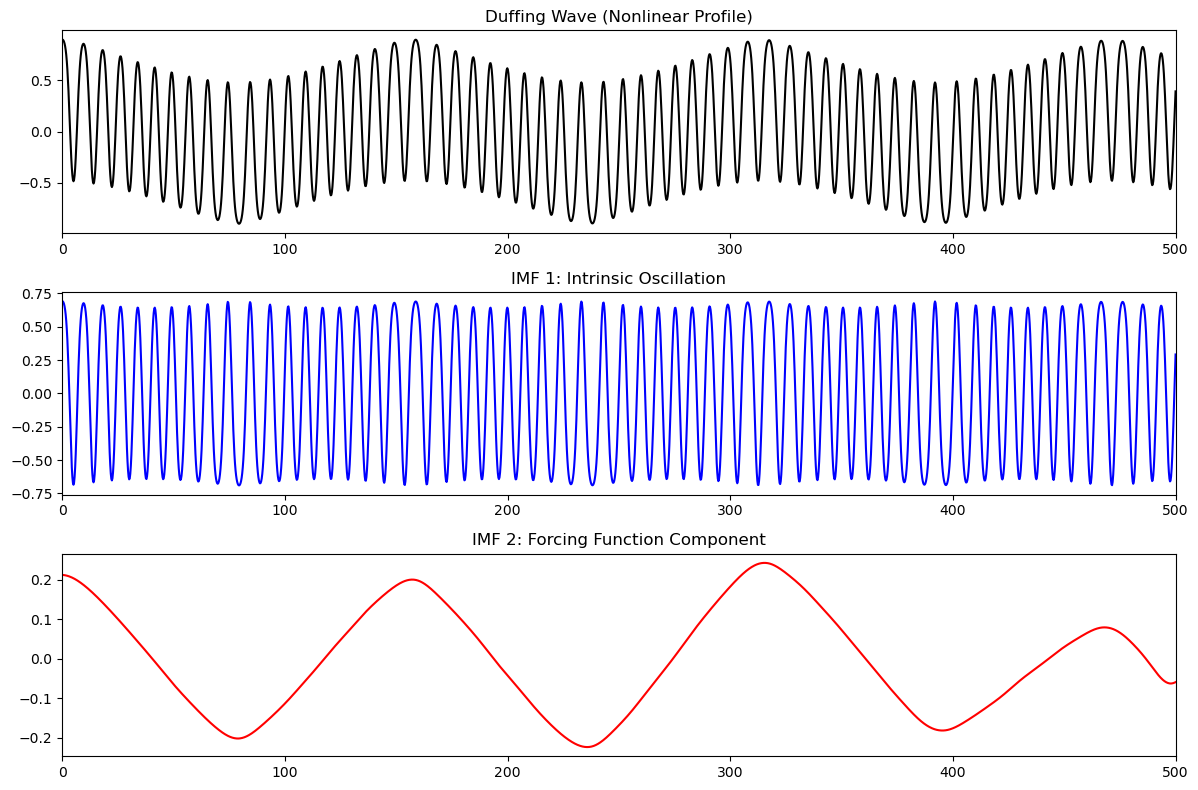

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from PyEMD import EMD

# 1. Define the Duffing system: x'' + x + epsilon*x^3 = gamma*cos(omega*t)
def duffing_system(state, t, epsilon, gamma, omega):
    x, v = state
    dxdt = v
    dvdt = -x - epsilon * (x**3) + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

# Parameters from Huang 1998: epsilon=-1 (soft spring), gamma=0.1, omega=1/25
# Potential V(x) = x²/2 - x⁴/4; separatrix at E=0.25 (x=±1, v=0)
t = np.linspace(0, 500, 2000)

# Was [1.0, 1.0]: energy = 0.5 > 0.25, unbounded motion with strong nonlinearities
state0 = [0.9, 0.0]  # E ≈ 0.231 < 0.25 (separatrix): near-separatrix → strongly nonlinear waveform
# [0.5, 0.0]: energy = 0.109 < 0.25, safely inside separatrix
state0 = [0.9, 0.0]  # E ≈ 0.231 < 0.25 (separatrix): near-separatrix → strongly nonlinear waveform

sol = odeint(duffing_system, state0, t, args=(-1.0, 0.1, 1/25))
signal = sol[:, 0]

# 2. Decompose using EMD
emd = EMD()
IMFs = emd(signal)

# 3. Visualization
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.xlim(t[0], t[-1])
plt.plot(t, signal, 'k')
plt.title("Duffing Wave (Nonlinear Profile)")
plt.subplot(3, 1, 2)
plt.xlim(t[0], t[-1])
plt.plot(t, IMFs[0], 'b')
plt.title("IMF 1: Intrinsic Oscillation")
plt.subplot(3, 1, 3)
plt.xlim(t[0], t[-1])
plt.plot(t, IMFs[1], 'r')
plt.title("IMF 2: Forcing Function Component")
plt.tight_layout()
plt.show()

### 12.2 The Lorenz Equation: Non-Stationary Chaos ###

The Lorenz system models atmospheric convection and is the foundational model for deterministic non-periodic flow (chaos):

$$\dot{x} = \sigma(y - x), \quad \dot{y} = x(r - z) - y, \quad \dot{z} = xy - bz$$

Its signals are chaotic and non-stationary, making the global Fourier spectrum misleading. This system provides a rigorous test for non-stationarity. Because the chaotic signal decays and shifts over time, a static Fourier spectrum is essentially meaningless, smearing energy across a broad band. EMD successfully tracks the "shifting" frequencies of the chaos as the system spirals toward its attractor. 

The Lorenz signal is highly transient. EMD successfully decomposes this into a few IMFs that track the shifting frequencies as the system spirals around its attractors, whereas Fourier analysis would simply smear the energy across a broad, meaningless frequency band.

In [ ]:
# 1. Define the Lorenz system
def lorenz_system(state, t, sigma, r, b):
    x, y, z = state
    return [sigma * (y - x), x * (r - z) - y, x * y - b * z]

# Parameters from Huang 1998: sigma=10, b=3, r=20
t_lorenz = np.linspace(0, 30, 3000)
state0_lorenz = [10.0, 0.0, 0.0]
sol_lorenz = odeint(lorenz_system, state0_lorenz, t_lorenz, args=(10, 20, 3))
z_component = sol_lorenz[:, 2] # Huang analyzed the z-component

# 2. Decompose
emd = EMD()
IMFs_lorenz = emd(z_component)

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.xlim(t_lorenz[0], t_lorenz[-1])
plt.plot(t_lorenz, z_component, 'g')
plt.title("Lorenz Z-Component (Chaotic/Transient)")
plt.subplot(2, 1, 2)
plt.xlim(t_lorenz[0], t_lorenz[-1])
plt.plot(t_lorenz, IMFs_lorenz[0], 'b')
plt.title("IMF 1: Primary Chaotic Oscillation")
plt.tight_layout()
plt.show()

### 12.3 The Rössler Equation: Period-Doubling and Non-Orthogonality ###

The Rössler system is utilized to study chaotic dynamics, particularly period-doubling. It is famous for period-doubling, where a signal contains two physical modes that are mathematically non-orthogonal.

$$\dot{x} = -(y + z), \quad \dot{y} = x + ay, \quad \dot{z} = b + z(x - c)$$

This demonstrates EMD's ability to handle non-orthogonal physical components. In period-doubling, distinct physical modes share harmonics in a Fourier expansion. Because linear methods insist on mathematical orthogonality, they cannot separate these modes. EMD, based on characteristic time scales rather than orthogonality, cleanly isolates the bimodal physical structure.

This is EMD's "breakthrough" moment. In period-doubling, the two modes share harmonics. Linear methods like Fourier analysis cannot separate them because they insist on mathematical orthogonality. EMD, which is based on characteristic time scales rather than orthogonality, cleanly separates the bimodal physical structure of the system.

In [ ]:
# 1. Define the Rössler system
def rossler_system(state, t, a, b, c):
    x, y, z = state
    return [-(y + z), x + a * y, b + z * (x - c)]

# Parameters from Huang 1998: a=0.2, b=0.2, c=3.5 (period-doubling case)
t_rossler = np.linspace(0, 150, 5000)
state0_rossler = [1.0, 1.0, 1.0]
sol_rossler = odeint(rossler_system, state0_rossler, t_rossler, args=(0.2, 0.2, 3.5))
x_rossler = sol_rossler[:, 0]

# 2. Decompose
emd = EMD()
IMFs_rossler = emd(x_rossler)

# 3. Plotting
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.xlim(t_rossler[0], t_rossler[-1])
plt.plot(t_rossler, x_rossler, 'm')
plt.title("Rössler X-Component (Period Doubling)")
plt.subplot(3, 1, 2)
plt.xlim(t_rossler[0], t_rossler[-1])
plt.plot(t_rossler, IMFs_rossler[0], 'b')
plt.title("IMF 1: Fast Scale")
plt.subplot(3, 1, 3)
plt.xlim(t_rossler[0], t_rossler[-1])
plt.plot(t_rossler, IMFs_rossler[1], 'r')
plt.title("IMF 2: Doubled Period Scale")
plt.tight_layout()
plt.show()

### 12.4 Computational Benchmark: EMD vs. FFT Implementation ###

The following Python script implements these three systems, performs EMD, and calculates the FFT to visually contrast the data-driven modes against the spurious harmonics of the Fourier transform.

In [ ]:
# conda install emd-signal matplotlib scipy ipykernel

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.fft import fft, fftfreq
from PyEMD import EMD

def plot_benchmark(t, signal, imfs, title):
    """Helper to visualize Signal, EMD Modes, and FFT Comparison."""
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, t[1] - t[0])[:n//2]
    
    plt.figure(figsize=(12, 8))
    
    # Subplot 1: Raw Signal
    plt.subplot(3, 1, 1)
    plt.xlim(t[0], t[-1])
    plt.plot(t, signal, 'k')
    plt.title(f"{title}: Original Nonlinear Wave")
    
    # Subplot 2: EMD Primary IMF
    plt.subplot(3, 1, 2)
    plt.xlim(t[0], t[-1])
    plt.plot(t, imfs[0], 'b')
    plt.title("EMD IMF 1: Adaptive Physical Mode")
    
    # Subplot 3: FFT Magnitude Spectrum
    plt.subplot(3, 1, 3)
    plt.plot(xf, 2.0/n * np.abs(yf[0:n//2]), 'r') # type: ignore
    plt.title("FFT Spectrum: Spurious Harmonics and Spectral Leakage")
    plt.xlim(0, 1) # Focused on low-freq benchmarks
    plt.tight_layout()
    plt.show()

# --- 1. DUFFING SYSTEM ---
def duffing(state, t):
    x, v = state
    # Soft spring (epsilon=-1): V(x) = x^2/2 - x^4/4
    # Separatrix at x=±1, v=0 (V_max=0.25)
    # Initial energy must be < 0.25 for bounded motion
    return [v, -x + x**3 + 0.1 * np.cos(1/25 * t)]

t_duff = np.linspace(0, 500, 2000)
# Was [1.0, 1.0]: energy = 0.5 > 0.25, unbounded motion with strong nonlinearities
sol_duff = odeint(duffing, [1.0, 1.0], t_duff)
# [0.5, 0.0]: energy = 0.109 < 0.25, safely inside separatrix
# sol_duff = odeint(duffing, [0.5, 0.0], t_duff)
sig_duff = sol_duff[:, 0]
emd = EMD()
imf_duff = emd(sig_duff)
plot_benchmark(t_duff, sig_duff, imf_duff, "Duffing Equation")

# --- 2. LORENZ SYSTEM ---
def lorenz(state, t):
    x, y, z = state
    return [10*(y - x), x*(20 - z) - y, x*y - 3*z]

t_lor = np.linspace(0, 30, 3000)
sol_lor = odeint(lorenz, [10.0, 0.0, 0.0], t_lor)
sig_lor = sol_lor[:, 2] # Analyzing the Z-component per Huang 1998
emd = EMD()
imf_lor = emd(sig_lor)
plot_benchmark(t_lor, sig_lor, imf_lor, "Lorenz Z-Component")

# --- 3. RÖSSLER SYSTEM (Period Doubling) ---
def rossler(state, t):
    x, y, z = state
    return [-(y + z), x + 0.2*y, 0.2 + z*(x - 3.5)]

t_ros = np.linspace(0, 150, 5000)
sol_ros = odeint(rossler, [1.0, 1.0, 1.0], t_ros)
sig_ros = sol_ros[:, 0]
emd = EMD()
imf_ros = emd(sig_ros)
plot_benchmark(t_ros, sig_ros, imf_ros, "Rössler X-Component")